In [1]:
#importing weather data for Luebeck
import pandas as pd
import requests
# URL of the webpage containing JSON data
url = "http://139.174.11.24/data?dataset=weatherdataforcities&start=2019-01-01&end=2023-12-31&cityName=Luebeck"

# Fetch the data from the URL
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Parse JSON data
    data = response.json()

    # Convert the data to a DataFrame
    Lueb_df = pd.DataFrame.from_dict(data , orient='index')

    # Reset the index to convert the timestamp to a column
    Lueb_df.reset_index(inplace=True)

else:
    print("Failed to fetch data. Status code:", response.status_code)





In [2]:

# drop unwanted columns

Lueb_df = Lueb_df.drop(columns = ["index", "time","snow","cityName"])
Lueb_df
Lueb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   temp    43824 non-null  float64
 1   dwpt    43824 non-null  float64
 2   rhum    43824 non-null  float64
 3   prcp    43824 non-null  float64
 4   wdir    43824 non-null  float64
 5   wspd    43824 non-null  float64
 6   wpgt    43824 non-null  float64
 7   pres    43824 non-null  float64
 8   tsun    43517 non-null  float64
 9   coco    43824 non-null  float64
dtypes: float64(10)
memory usage: 3.3 MB


In [3]:
Lueb_df.head()

,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco
0,7.8,5.6,86.0,0.0,250.0,20.5,42.0,1023.6,0.0,8.0
1,8.0,4.9,81.0,0.0,250.0,20.2,47.0,1022.5,0.0,4.0
2,8.0,4.9,81.0,0.0,250.0,21.2,41.0,1022.0,0.0,4.0
3,8.0,4.8,80.0,0.0,250.0,23.0,45.0,1020.3,0.0,4.0
4,7.4,6.0,91.0,0.0,250.0,24.5,46.0,1019.0,0.0,8.0


In [4]:
#Checking for null values
Lueb_df.isnull().sum()

temp      0
dwpt      0
rhum      0
prcp      0
wdir      0
wspd      0
wpgt      0
pres      0
tsun    307
coco      0
dtype: int64

In [ ]:
# find the percentage of missing values in each feature
Lueb_df.isnull().sum()/len(Lueb_df) *100

temp    0.000000
dwpt    0.000000
rhum    0.000000
prcp    0.000000
wdir    0.000000
wspd    0.000000
wpgt    0.000000
pres    0.000000
tsun    0.700529
coco    0.000000
dtype: float64

In [ ]:
mask_nntsun = Lueb_df['tsun'].isnull()
Lueb_df[mask_nntsun]

,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco
1197,6.5,4.3,86.0,0.0,260.0,18.0,35.2,1015.5,NaN,17.0
1198,6.5,4.3,86.0,0.0,260.0,16.6,35.2,1015.9,NaN,17.0
1199,6.4,4.2,86.0,0.0,250.0,18.4,33.3,1015.9,NaN,17.0
1200,6.4,4.1,85.0,0.0,260.0,16.6,35.2,1016.2,NaN,17.0
1201,6.7,3.8,82.0,0.0,260.0,17.6,33.3,1016.7,NaN,7.0
...,...,...,...,...,...,...,...,...,...,...
30749,12.9,10.4,85.0,0.0,210.0,5.0,13.0,1019.6,NaN,3.0
30750,15.5,11.1,75.0,0.0,240.0,7.9,18.0,1020.1,NaN,2.0
30751,16.6,11.3,71.0,0.0,250.0,11.5,23.0,1020.4,NaN,4.0
30752,17.3,10.7,65.0,0.0,260.0,11.2,26.0,1020.6,NaN,4.0


In [ ]:
#Using Linear Regression Imputation to fill missing values in the tsun feature
from sklearn.linear_model import LinearRegression

# seperate the null  values of the tsun feature
test =  Lueb_df[Lueb_df["tsun"].isnull()]
X_test = test.drop(columns = ["tsun","coco","wpgt"] )

#Dropping the null values from the dataset
train = Lueb_df.dropna()
#Splitting the train data into target and feature
X_train= train.drop(columns = ["tsun","coco","wpgt"])
y_train = train["tsun"]

#Calling the linear regression model
lr = LinearRegression()
#Fitting the tranining data in to the model
lr.fit(X_train, y_train)
#Predicting the missing tsun values
y_pred = lr.predict(X_test)

#Replacing the missing values with the model prediction
Lueb_df.loc[Lueb_df.tsun.isnull(),"tsun"] = y_pred






In [ ]:
#Check if missing values still exists for the tsun feature
Lueb_df.isnull().sum()/len(Lueb_df) *100

temp    0.0
dwpt    0.0
rhum    0.0
prcp    0.0
wdir    0.0
wspd    0.0
wpgt    0.0
pres    0.0
tsun    0.0
coco    0.0
dtype: float64

In [ ]:
# Check if -99999 exists in all columns and print columns where it exists
columns_with_value = Lueb_df.apply(lambda col: col.name if -99999 in col.values else None).dropna()

if len(columns_with_value) > 0:
    print(f"The value '{-99999}' exists in the following columns:")
    for col in columns_with_value:
        print(col)
else:
    print(f"The value '{-99999}' does not exist in any column.")

The value '-99999' does not exist in any column.


In [ ]:
Lueb_df.describe()

,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco
count,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.00000,43824.000000,43824.000000,43824.000000
mean,10.182621,6.209114,78.735328,0.073626,192.087121,10.491343,21.67673,1014.744971,11.719454,4.402633
std,7.125718,5.934764,16.518970,0.407266,83.538681,6.202175,11.78252,10.523836,20.877914,2.705998
min,-17.000000,-18.500000,18.000000,0.000000,0.000000,0.000000,1.00000,974.900000,-1.057778,0.000000
25%,4.900000,1.900000,69.000000,0.000000,130.000000,6.100000,13.00000,1008.100000,0.000000,3.000000
50%,9.700000,6.300000,83.000000,0.000000,210.000000,9.400000,20.00000,1015.500000,0.000000,4.000000
75%,15.300000,10.800000,92.000000,0.000000,260.000000,13.700000,28.00000,1021.600000,14.000000,7.000000
max,37.700000,21.700000,100.000000,24.100000,360.000000,50.000000,98.00000,1048.400000,60.000000,25.000000


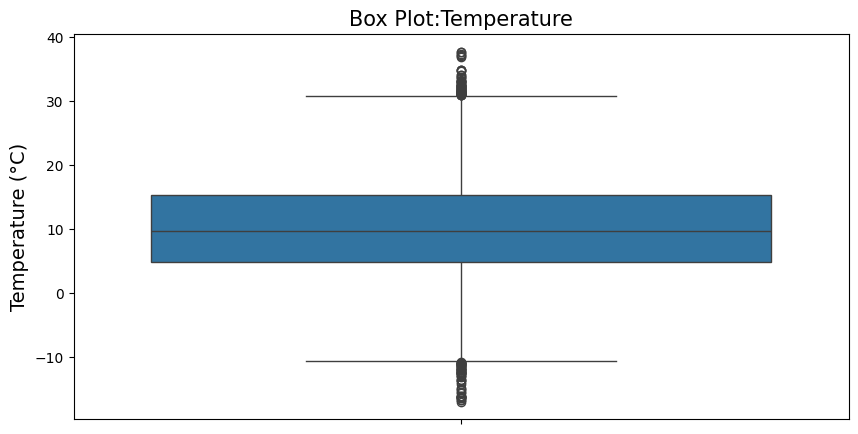

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig = plt.figure(figsize=(10,5))
sns.boxplot(Lueb_df.temp)
plt.title('Box Plot:Temperature', fontsize=15)
plt.ylabel('Temperature (°C)', fontsize=14)
plt.show()

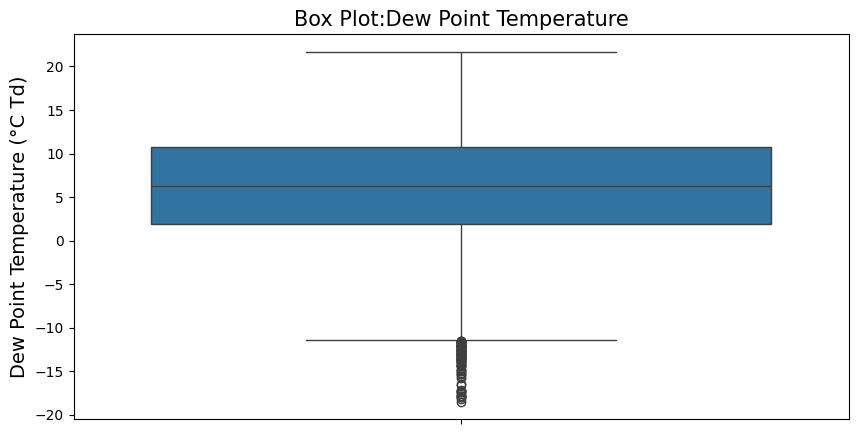

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Lueb_df.dwpt)
plt.title('Box Plot:Dew Point Temperature', fontsize=15)
plt.ylabel('Dew Point Temperature (°C Td)', fontsize=14)
plt.show()

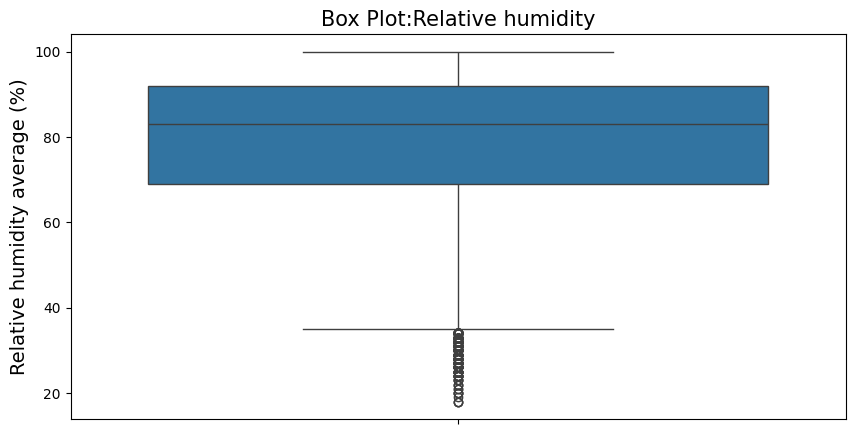

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Lueb_df.rhum)
plt.title('Box Plot:Relative humidity', fontsize=15)
plt.ylabel('Relative humidity average (%)', fontsize=14)
plt.show()

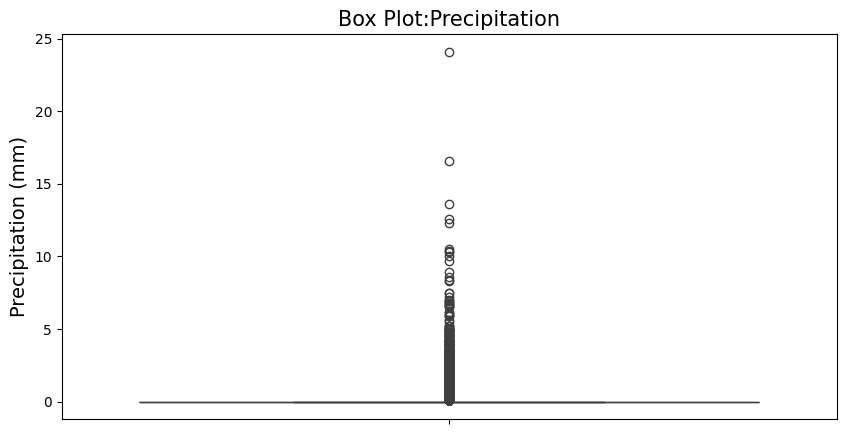

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Lueb_df.prcp)
plt.title('Box Plot:Precipitation', fontsize=15)
plt.ylabel('Precipitation (mm)', fontsize=14)
plt.show()

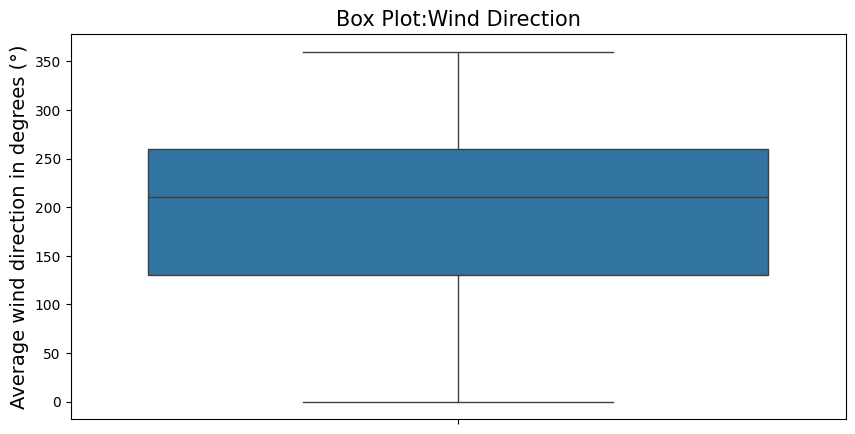

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Lueb_df.wdir)
plt.title('Box Plot:Wind Direction', fontsize=15)
plt.ylabel('Average wind direction in degrees (°)', fontsize=14)
plt.show()

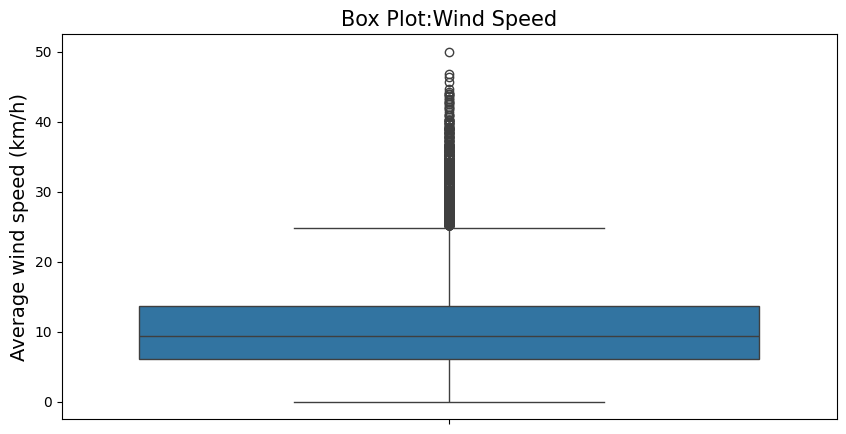

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Lueb_df.wspd)
plt.title('Box Plot:Wind Speed', fontsize=15)
plt.ylabel('Average wind speed (km/h)', fontsize=14)
plt.show()

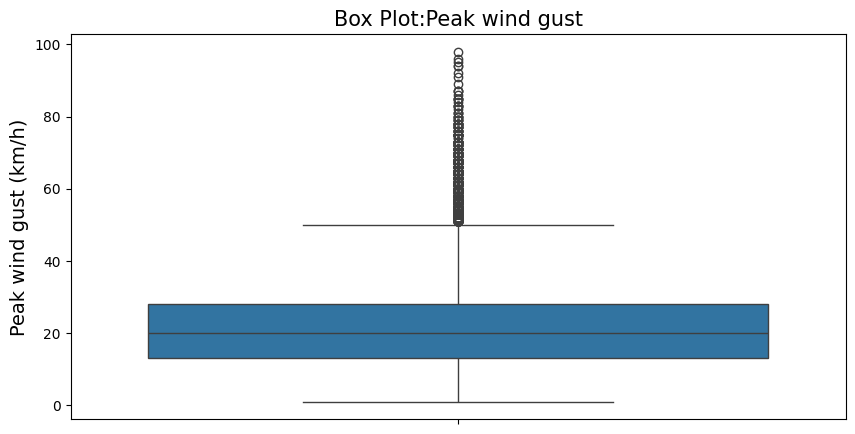

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Lueb_df.wpgt)
plt.title('Box Plot:Peak wind gust', fontsize=15)
plt.ylabel('Peak wind gust (km/h)', fontsize=14)
plt.show()

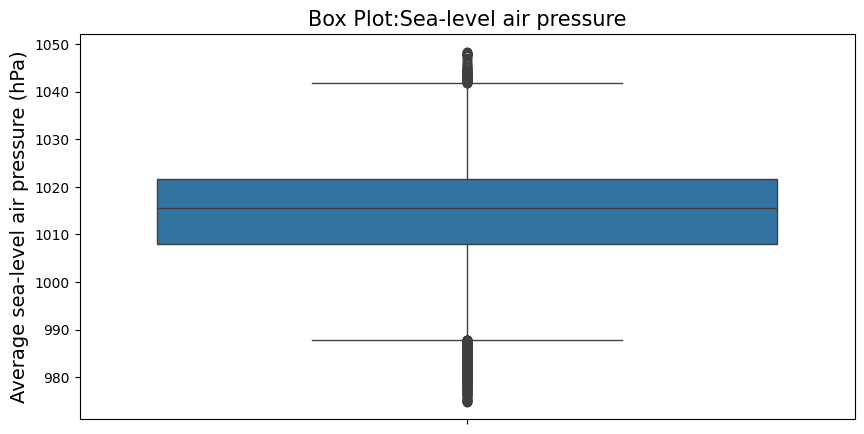

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Lueb_df.pres)
plt.title('Box Plot:Sea-level air pressure', fontsize=15)
plt.ylabel('Average sea-level air pressure (hPa)', fontsize=14)
plt.show()

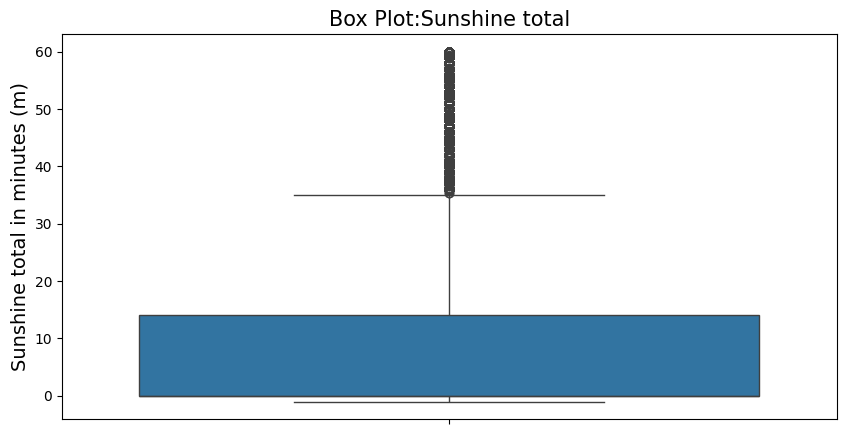

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Lueb_df.tsun)
plt.title('Box Plot:Sunshine total', fontsize=15)
plt.ylabel('Sunshine total in minutes (m)', fontsize=14)
plt.show()

In [ ]:
Lueb_df["tsun"].max()

60.0

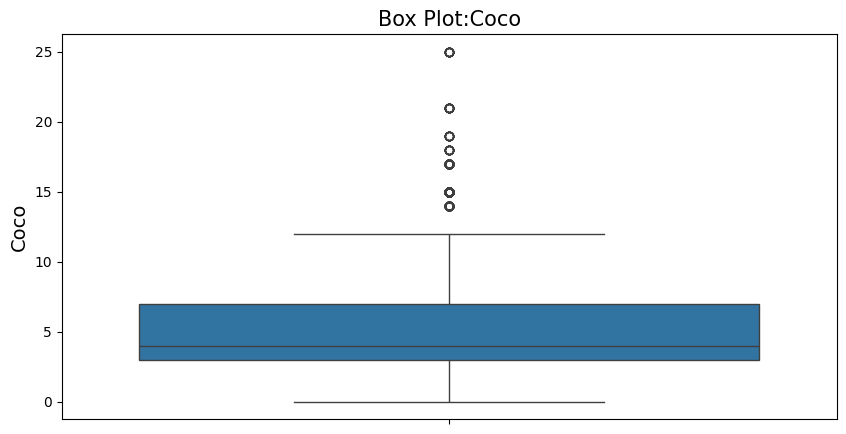

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Lueb_df.coco)
plt.title('Box Plot:Coco', fontsize=15)
plt.ylabel('Coco', fontsize=14)
plt.show()

In [ ]:
mask_ntsun = Lueb_df['tsun'] > 0.0
Lueb_df[mask_ntsun]

,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco
10,7.5,3.0,73.0,0.0,280.0,25.6,44.0,1016.9,9.0,4.0
11,7.9,2.1,67.0,0.0,280.0,29.9,62.0,1016.2,19.0,4.0
12,7.4,1.5,66.0,0.0,290.0,33.5,58.0,1015.4,17.0,8.0
13,6.7,1.2,68.0,0.0,290.0,34.6,74.0,1015.2,7.0,8.0
14,6.3,0.4,66.0,0.0,290.0,34.2,76.0,1015.3,16.0,8.0
...,...,...,...,...,...,...,...,...,...,...
43764,8.8,5.0,77.0,0.0,230.0,12.2,35.0,1001.5,24.0,3.0
43765,8.9,5.3,78.0,0.0,220.0,12.6,39.0,1001.2,4.0,8.0
43766,9.4,4.6,72.0,0.0,230.0,15.1,39.0,1000.9,29.0,8.0
43767,9.1,2.9,65.0,0.0,240.0,23.0,52.0,1001.5,3.0,8.0


In [ ]:
mask_tsun = Lueb_df['tsun'] == 0.0
mask_prcp = Lueb_df['prcp'] ==0.0
Lueb_df[mask_tsun & mask_prcp]

,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco
0,7.8,5.6,86.0,0.0,250.0,20.5,42.0,1023.6,0.0,8.0
1,8.0,4.9,81.0,0.0,250.0,20.2,47.0,1022.5,0.0,4.0
2,8.0,4.9,81.0,0.0,250.0,21.2,41.0,1022.0,0.0,4.0
3,8.0,4.8,80.0,0.0,250.0,23.0,45.0,1020.3,0.0,4.0
4,7.4,6.0,91.0,0.0,250.0,24.5,46.0,1019.0,0.0,8.0
...,...,...,...,...,...,...,...,...,...,...
43812,6.6,3.9,83.0,0.0,140.0,16.2,32.0,1001.1,0.0,8.0
43814,6.9,3.9,81.0,0.0,140.0,15.8,32.0,999.0,0.0,8.0
43817,7.2,4.2,81.0,0.0,150.0,12.6,29.0,998.5,0.0,4.0
43821,6.3,4.3,87.0,0.0,180.0,8.3,19.0,1000.0,0.0,4.0


In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import LocalOutlierFactor


# Number of neighbors for LOF
n_neighbors = 20
contamination = 0.10
# Dictionary to store the percentage of outliers for each feature
outlier_percentages = {}

# Apply LOF to each feature
for feature in Lueb_df.columns:
# Reshape the data for LOF
 X = Lueb_df[[feature]].values

 # Fit the LOF model
 lof = LocalOutlierFactor(n_neighbors=n_neighbors)
 y_pred = lof.fit_predict(X)

 # Identify the outliers
 outliers = y_pred == -1

 # Calculate the percentage of outliers
 percentage_outliers = np.mean(outliers) * 100
 outlier_percentages[feature] = percentage_outliers

 print(f'Percentage of outliers in Luebeck weather {feature}: {percentage_outliers:.2f}%')

Percentage of outliers in Luebeck weather temp: 0.24%
Percentage of outliers in Luebeck weather dwpt: 0.20%
Percentage of outliers in Luebeck weather rhum: 0.05%
Percentage of outliers in Luebeck weather prcp: 0.12%
Percentage of outliers in Luebeck weather wdir: 0.44%
Percentage of outliers in Luebeck weather wspd: 0.11%
Percentage of outliers in Luebeck weather wpgt: 0.17%
Percentage of outliers in Luebeck weather pres: 0.98%
Percentage of outliers in Luebeck weather tsun: 0.70%
Percentage of outliers in Luebeck weather coco: 0.08%


USING NAIVE BAYES FOR WEATHER DATASET


In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from scipy.stats import norm


# Extract features
X = Lueb_df.values

# Fit Gaussian Naive Bayes model
gnb = GaussianNB()
gnb.fit(X, np.zeros(X.shape[0]))  # Dummy target variable

# Calculate likelihoods for each data point
means = gnb.theta_
variances = gnb.var_
likelihoods = np.zeros(X.shape[0])

# Ensure means and variances are in correct shape
if means.ndim == 1:
    means = means.reshape(1, -1)
if variances.ndim == 1:
    variances = variances.reshape(1, -1)

# Calculate likelihoods for each data point
for i, x in enumerate(X):
    likelihood = 1
    for j in range(X.shape[1]):
        likelihood *= norm.pdf(x[j], loc=means[0][j], scale=np.sqrt(variances[0][j]))
    likelihoods[i] = likelihood

# Determine anomalies
threshold = np.percentile(likelihoods, 10)  # for example, consider the bottom 10% as anomalies
anomalies = np.where(likelihoods < threshold)[0]

# Calculate percentage of anomalies for each feature
anomalies_weather_data = Lueb_df.iloc[anomalies]
total_anomalies = len(anomalies)
total_data_points = len(Lueb_df)

# Calculate anomaly percentage for each feature
feature_anomalies_percentage = {}
for feature in Lueb_df.columns:
    feature_anomalies_count = (anomalies_weather_data[feature] != Lueb_df[feature].mode().iloc[0]).sum()
    feature_anomalies_percentage[feature] = (feature_anomalies_count / total_data_points) * 100

print("Number of anomalies detected:", total_anomalies)
print("Percentage of anomalies for each feature:")
for feature, percentage in feature_anomalies_percentage.items():
    print(f"{feature}: {percentage:.2f}%")

Number of anomalies detected: 4383
Percentage of anomalies for each feature:
temp: 9.93%
dwpt: 9.96%
rhum: 9.73%
prcp: 2.70%
wdir: 9.43%
wspd: 9.83%
wpgt: 9.77%
pres: 9.98%
tsun: 5.51%
coco: 8.70%


In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from scipy.stats import norm



# Initialize a dictionary to store anomaly information for each feature
anomaly_info = {}

# Loop through each feature
for feature in Lueb_df.columns:
    # Extract the feature values
    X = Lueb_df[[feature]].values

    # Fit Gaussian Naive Bayes model
    gnb = GaussianNB()
    gnb.fit(X, np.zeros(X.shape[0]))  # Dummy target variable

    # Calculate likelihoods for each data point
    means = gnb.theta_
    variances = gnb.var_
    likelihoods = np.zeros(X.shape[0])

    # Ensure means and variances are in correct shape
    if means.ndim == 1:
        means = means.reshape(1, -1)
    if variances.ndim == 1:
        variances = variances.reshape(1, -1)

    # Calculate likelihoods for each data point
    for i, x in enumerate(X):
        likelihood = norm.pdf(x[0], loc=means[0][0], scale=np.sqrt(variances[0][0]))
        likelihoods[i] = likelihood

    # Determine anomalies using mean and standard deviation
    mean_likelihood = np.mean(likelihoods)
    std_likelihood = np.std(likelihoods)
    threshold = mean_likelihood - 2 * std_likelihood  # 2 standard deviations below the mean
    anomalies = np.where(likelihoods < threshold)[0]

    # Calculate percentage of anomalies for this feature
    total_anomalies = len(anomalies)
    total_data_points = len(Lueb_df)
    anomaly_percentage = (total_anomalies / total_data_points) * 100

    # Store the anomaly information
    anomaly_info[feature] = {
        'total_anomalies': total_anomalies,
        'anomaly_percentage': anomaly_percentage,
        'anomalies': anomalies
    }

# Print results
for feature, info in anomaly_info.items():
    print(f"Feature: {feature}")
    print(f"  Number of anomalies detected: {info['total_anomalies']}")
    print(f"  Percentage of anomalies: {info['anomaly_percentage']:.2f}%")



Feature: temp
  Number of anomalies detected: 2079
  Percentage of anomalies: 4.74%
Feature: dwpt
  Number of anomalies detected: 1738
  Percentage of anomalies: 3.97%
Feature: rhum
  Number of anomalies detected: 2928
  Percentage of anomalies: 6.68%
Feature: prcp
  Number of anomalies detected: 1970
  Percentage of anomalies: 4.50%
Feature: wdir
  Number of anomalies detected: 1235
  Percentage of anomalies: 2.82%
Feature: wspd
  Number of anomalies detected: 2344
  Percentage of anomalies: 5.35%
Feature: wpgt
  Number of anomalies detected: 2265
  Percentage of anomalies: 5.17%
Feature: pres
  Number of anomalies detected: 2620
  Percentage of anomalies: 5.98%
Feature: tsun
  Number of anomalies detected: 5494
  Percentage of anomalies: 12.54%
Feature: coco
  Number of anomalies detected: 836
  Percentage of anomalies: 1.91%


AUTOENCODER ON WEATHER DATSET

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential



#to save all features
features_auto_w = Lueb_df.columns.tolist()


# DataFrame to store anomaly scores for each feature
anomaly_scores_auto_w = pd.DataFrame(index=Lueb_df.index)

# Loop through each feature
for feature in features_auto_w :
    # Scale the feature data
    scaler = MinMaxScaler()
    scaled_feature_auto_w  = scaler.fit_transform(Lueb_df[[feature]])

    # Define the autoencoder model
    model_auto_w  = Sequential([
        Dense(32, activation='relu', input_shape=(1,)),
        Dense(16, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model_auto_w .compile(optimizer='adam', loss='mean_squared_error')

     #Train the autoencoder
    model_auto_w.fit(scaled_feature_auto_w , scaled_feature_auto_w , epochs=50, batch_size=32, validation_split=0.1, verbose=0)

    # Get reconstruction loss
    reconstructed_feature_auto_w  = model_auto_w.predict(scaled_feature_auto_w )
    reconstruction_loss_auto_w  = np.mean(np.square(scaled_feature_auto_w  - reconstructed_feature_auto_w ), axis=1)

    # Store the reconstruction loss (anomaly score) in the DataFrame
    anomaly_scores_auto_w [feature] = reconstruction_loss_auto_w



1370/1370 [==============================] - 2s 1ms/step


In [ ]:

print(reconstruction_loss_auto_w)
# Calculate the threshold as the 90th percentile of the reconstruction loss
threshold_auto_w = np.percentile(reconstruction_loss_auto_w, 90)

    # Identify anomalies
anomalies_auto_w = reconstruction_loss_auto_w > threshold_auto_w

for feature in features_auto_w:
    anomalies_auto_w = anomaly_scores_auto_w[feature] > threshold_auto_w
    anomaly_percentage_auto_w = np.mean(anomalies_auto_w) * 100
    print(f'Feature: {feature}, Anomaly Percentage: {anomaly_percentage_auto_w:.2f}%')


    # Store the reconstruction loss (anomaly score) in the DataFrame
anomaly_scores_auto_w[feature] = reconstruction_loss_auto_w


# Combine anomaly scores with original data for easier analysis
combined_data_auto_w = pd.concat([Lueb_df, anomaly_scores_auto_w.add_suffix('_anomaly_score')], axis=1)

# Save the combined data with anomaly scores
combined_data_auto_w.to_csv('Lueb_df_with_anomaly_scores_auto_w.csv', index=False)

# Display the first few rows of the combined data
combined_data_auto_w.head()

[2.28283760e-08 1.72331151e-07 1.72331151e-07 ... 1.72331151e-07
 2.28283760e-08 2.28283760e-08]
Feature: temp, Anomaly Percentage: 96.15%
Feature: dwpt, Anomaly Percentage: 77.75%
Feature: rhum, Anomaly Percentage: 84.68%
Feature: prcp, Anomaly Percentage: 6.90%
Feature: wdir, Anomaly Percentage: 89.09%
Feature: wspd, Anomaly Percentage: 89.97%
Feature: wpgt, Anomaly Percentage: 60.48%
Feature: pres, Anomaly Percentage: 88.98%
Feature: tsun, Anomaly Percentage: 29.93%
Feature: coco, Anomaly Percentage: 6.85%


,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco,temp_anomaly_score,dwpt_anomaly_score,rhum_anomaly_score,prcp_anomaly_score,wdir_anomaly_score,wspd_anomaly_score,wpgt_anomaly_score,pres_anomaly_score,tsun_anomaly_score,coco_anomaly_score
0,7.8,5.6,86.0,0.0,250.0,20.5,42.0,1023.6,0.0,8.0,0.000046,1.546856e-06,6.356677e-07,9.327581e-09,0.000016,8.993414e-07,0.000002,4.710396e-08,3.189134e-11,2.282838e-08
1,8.0,4.9,81.0,0.0,250.0,20.2,47.0,1022.5,0.0,4.0,0.000044,2.323916e-06,2.964217e-07,9.327581e-09,0.000016,9.950613e-07,0.000001,5.946358e-07,3.189134e-11,1.723312e-07
2,8.0,4.9,81.0,0.0,250.0,21.2,41.0,1022.0,0.0,4.0,0.000044,2.323916e-06,2.964217e-07,9.327581e-09,0.000016,7.803348e-07,0.000002,1.284565e-06,3.189134e-11,1.723312e-07
3,8.0,4.8,80.0,0.0,250.0,23.0,45.0,1020.3,0.0,4.0,0.000044,2.393184e-06,1.434775e-06,9.327581e-09,0.000016,1.480185e-06,0.000002,3.963627e-06,3.189134e-11,1.723312e-07
4,7.4,6.0,91.0,0.0,250.0,24.5,46.0,1019.0,0.0,8.0,0.000050,9.537676e-07,2.921505e-07,9.327581e-09,0.000016,3.347014e-06,0.000001,5.263931e-06,3.189134e-11,2.282838e-08


In [ ]:

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Sample Data (Replace with your dataset)
# Assuming a dataframe with 100 rows and 10 features


# Define anomaly detection function
def detect_anomalies(Mun_df):
    anomalies = pd.DataFrame(index=Mun_df.index)
    anomaly_percentages = {}

    for feature in Mun_df.columns:
        X = Mun_df.drop(columns=[feature])
        y = Mun_df[feature]

        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Train XGBoost model
        model = XGBRegressor()
        model.fit(X_train, y_train)

        # Predict on the whole dataset
        y_pred = model.predict(X)

        # Calculate prediction errors
        errors = np.abs(y - y_pred)

        # Determine dynamic threshold using standard deviation
        mean_error = np.mean(errors)
        std_error = np.std(errors)
        threshold = mean_error + 2 * std_error  # Consider 2 standard deviations from the mean

        # Flag anomalies
        anomaly_flags = errors > threshold
        anomalies[feature] = anomaly_flags

        # Calculate anomaly percentage
        anomaly_percentages[feature] = (anomaly_flags.sum() / len(Mun_df)) * 100

        # Print summary
        print(f"Feature: {feature}")
        print(f"Threshold: {threshold:.4f}")
        print(f"Anomalies detected: {anomaly_flags.sum()}/{len(Mun_df)} ({anomaly_percentages[feature]:.2f}%)")
        print("-" * 40)

    return anomalies, anomaly_percentages

# Detect anomalies
anomalies_df, anomaly_percentages = detect_anomalies(Lueb_df)


# Print anomaly percentages
print("\nAnomaly Percentages per Feature:")
for feature, percentage in anomaly_percentages.items():
    print(f"{feature}: {percentage:.2f}%")


Feature: temp
Threshold: 0.2778
Anomalies detected: 1530/43824 (3.49%)
----------------------------------------
Feature: dwpt
Threshold: 0.3124
Anomalies detected: 1061/43824 (2.42%)
----------------------------------------
Feature: rhum
Threshold: 2.4009
Anomalies detected: 1878/43824 (4.29%)
----------------------------------------
Feature: prcp
Threshold: 0.4537
Anomalies detected: 1183/43824 (2.70%)
----------------------------------------
Feature: wdir
Threshold: 127.0475
Anomalies detected: 2320/43824 (5.29%)
----------------------------------------
Feature: wspd
Threshold: 2.5236
Anomalies detected: 1812/43824 (4.13%)
----------------------------------------
Feature: wpgt
Threshold: 5.0794
Anomalies detected: 1754/43824 (4.00%)
----------------------------------------
Feature: pres
Threshold: 14.6493
Anomalies detected: 2182/43824 (4.98%)
----------------------------------------
Feature: tsun
Threshold: 23.4738
Anomalies detected: 2594/43824 (5.92%)
-----------------------------

IRRADIATION DATASET

In [5]:
import pandas as pd
import requests
#importing irradiation data for Meiningen
# URL of the webpage containing JSON data
url = "http://139.174.11.24/data?dataset=irradiationdataforcities&start=2019-01-01&end=2023-12-31&cityName=Luebeck"

# Fetch the data from the URL
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Parse JSON data
    data = response.json()

    # Convert the data to a DataFrame
    Lueb_irrad = pd.DataFrame.from_dict(data, orient='index')


else:
    print("Failed to fetch data. Status code:", response.status_code)


In [6]:
Lueb_irrad.head(2)

,time,Observation period,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI,Reliability,cityName
1546300800000,2019-01-01 00:00:00,2019-01-01T00:00:00.0/2019-01-01T00:15:00.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,1.0000,Luebeck
1546301700000,2019-01-01 00:15:00,2019-01-01T00:15:00.0/2019-01-01T00:30:00.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,1.0000,Luebeck


In [7]:

# drop unwanted columns
Lueb_clean_df = Lueb_irrad.drop(columns = ["time", "Observation period", "Reliability", "cityName"])
Lueb_irrad.info()

<class 'pandas.core.frame.DataFrame'>
Index: 175296 entries, 1546300800000 to 1704066300000
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   time                175296 non-null  object 
 1   Observation period  175296 non-null  object 
 2   TOA                 175296 non-null  object 
 3   Clear sky GHI       175296 non-null  object 
 4   Clear sky BHI       175296 non-null  object 
 5   Clear sky DHI       175296 non-null  object 
 6   Clear sky BNI       175296 non-null  object 
 7   GHI                 175296 non-null  float64
 8   BHI                 175296 non-null  object 
 9   DHI                 175296 non-null  object 
 10  BNI                 175296 non-null  object 
 11  Reliability         175296 non-null  object 
 12  cityName            175296 non-null  object 
dtypes: float64(1), object(12)
memory usage: 18.7+ MB


In [ ]:
df_lueb = Lueb_clean_df.select_dtypes("object").astype("float")
df_m["GHI"] =  Lueb_clean_df["GHI"]

In [8]:
#Get the percentage of null values in the dataset
Lueb_clean_df.isnull().sum() /len(Lueb_clean_df) *(100)

TOA              0.0
Clear sky GHI    0.0
Clear sky BHI    0.0
Clear sky DHI    0.0
Clear sky BNI    0.0
GHI              0.0
BHI              0.0
DHI              0.0
BNI              0.0
dtype: float64

In [9]:
Lueb_clean_df.describe()

,GHI
count,175296.000000
mean,31.394246
std,50.897773
min,0.000000
25%,0.000000
50%,0.469250
75%,44.609700
max,228.903700


In [ ]:
Lueb_clean_df.head(2)

,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI
1546300800000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546301700000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000


In [ ]:

# Check if -99999 exists in all columns and print columns where it exists
columns_with_value = Lueb_clean_df.apply(lambda col: col.name if -99999 in col.values else None).dropna()

if len(columns_with_value) > 0:
    print(f"The value '{-99999}' exists in the following columns:")
    for col in columns_with_value:
        print(col)
else:
    print(f"The value '{-99999}' does not exist in any column.")

The value '-99999' does not exist in any column.


In [ ]:
Lueb_clean_df

,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI
1546300800000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546301700000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546302600000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546303500000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546304400000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...
1704062700000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1704063600000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1704064500000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1704065400000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000


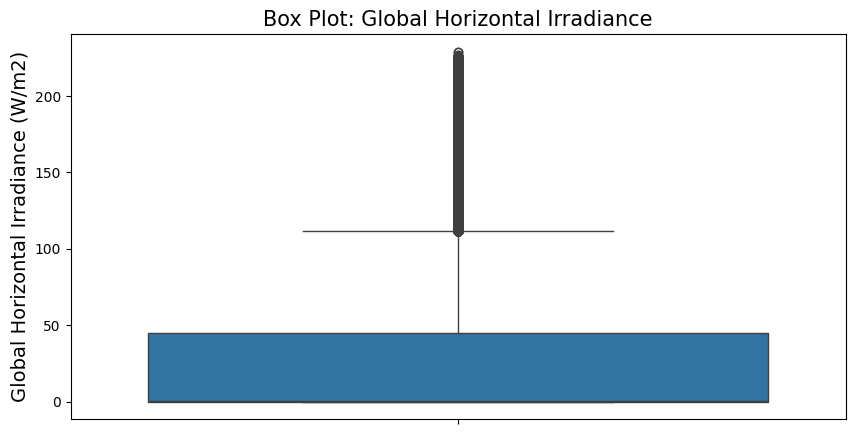

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Lueb_clean_df.GHI)
plt.title('Box Plot: Global Horizontal Irradiance', fontsize=15)
plt.ylabel('Global Horizontal Irradiance (W/m2)', fontsize=14)
plt.show()

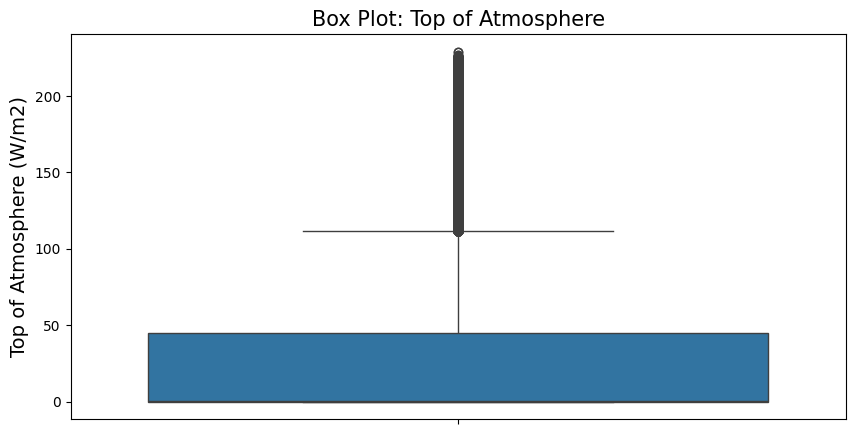

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Lueb_clean_df.GHI)
plt.title('Box Plot: Top of Atmosphere', fontsize=15)
plt.ylabel('Top of Atmosphere (W/m2)', fontsize=14)
plt.show()

In [ ]:
Lueb_clean = Lueb_clean_df.select_dtypes(include=['object']).astype('float')
Lueb_clean["GHI"] = Lueb_clean_df["GHI"]
Lueb_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 175296 entries, 1546300800000 to 1704066300000
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TOA            175296 non-null  float64
 1   Clear sky GHI  175296 non-null  float64
 2   Clear sky BHI  175296 non-null  float64
 3   Clear sky DHI  175296 non-null  float64
 4   Clear sky BNI  175296 non-null  float64
 5   BHI            175296 non-null  float64
 6   DHI            175296 non-null  float64
 7   BNI            175296 non-null  float64
 8   GHI            175296 non-null  float64
dtypes: float64(9)
memory usage: 13.4+ MB


In [ ]:
mask = Lueb_clean["GHI"] == 0.0
(len(Lueb_clean[mask])/len(Lueb_clean)) *100


48.75924151150055

LOF PER FEATURES OF IRRADIATION DATASET

In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import LocalOutlierFactor

# Number of neighbors for LOF
n_neighbors = 20
contamination = 0.10
# Dictionary to store the percentage of outliers for each feature
outlier_percentages = {}

# Apply LOF to each feature
for feature in Lueb_clean_df.columns:
# Reshape the data for LOF
 X = Lueb_clean_df[[feature]].values

 # Fit the LOF model
 lof = LocalOutlierFactor(n_neighbors=n_neighbors)
 y_pred = lof.fit_predict(X)

 # Identify the outliers
 outliers = y_pred == -1

 # Calculate the percentage of outliers
 percentage_outliers = np.mean(outliers) * 100
 outlier_percentages[feature] = percentage_outliers

 print(f'Percentage of outliers in Luebeck irradiation in {feature}: {percentage_outliers:.2f}%')

Percentage of outliers in Luebeck irradiation in TOA: 0.06%
Percentage of outliers in Luebeck irradiation in Clear sky GHI: 0.02%
Percentage of outliers in Luebeck irradiation in Clear sky BHI: 0.09%
Percentage of outliers in Luebeck irradiation in Clear sky DHI: 0.01%
Percentage of outliers in Luebeck irradiation in Clear sky BNI: 0.01%
Percentage of outliers in Luebeck irradiation in GHI: 0.02%
Percentage of outliers in Luebeck irradiation in BHI: 0.11%
Percentage of outliers in Luebeck irradiation in DHI: 0.01%
Percentage of outliers in Luebeck irradiation in BNI: 0.07%


USING NAIVE BAYES ON THE IRRADIATION DATASET

In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from scipy.stats import norm

# Assuming clean_Osna_Irrad is your DataFrame loaded from your dataset
# Example steps to handle data types and missing values

# Step 1: Check and Convert Data Types
# Convert all columns to numeric (float64)
Lueb_clean_df = Lueb_clean_df.apply(pd.to_numeric, errors='coerce')

# Step 2: Handle Missing Values
Lueb_clean_df = Lueb_clean_df.dropna()  # Drop rows with NaN values

# Extract features
X = Lueb_clean_df.values

# Fit Gaussian Naive Bayes model
gnb = GaussianNB()
gnb.fit(X, np.zeros(X.shape[0]))  # Dummy target variable

# Calculate likelihoods for each data point
means = gnb.theta_
variances = np.var(X, axis=0) + 1e-9  # Adding a small value for numerical stability

likelihoods = np.zeros(X.shape[0])

# Ensure means and variances are in correct shape
if means.ndim == 1:
    means = means.reshape(1, -1)
if variances.ndim == 1:
    variances = variances.reshape(1, -1)

# Calculate likelihoods for each data point
for i, x in enumerate(X):
    likelihood = 1
    for j in range(X.shape[1]):
        likelihood *= norm.pdf(x[j], loc=means[0][j], scale=np.sqrt(variances[0][j]))
    likelihoods[i] = likelihood

# Determine anomalies
threshold = np.percentile(likelihoods, 10)  # for example, consider the bottom 10% as anomalies
anomalies = np.where(likelihoods < threshold)[0]

# Calculate percentage of anomalies for each feature
anomalies_Lueb_clean_df = Lueb_clean_df.iloc[anomalies]
total_anomalies = len(anomalies)
total_data_points = len(Lueb_clean_df)

# Calculate anomaly percentage for each feature
feature_anomalies_percentage = {}
for feature in Lueb_clean_df.columns:
    feature_anomalies_count = (anomalies_Lueb_clean_df[feature] != Lueb_clean_df[feature].mode().iloc[0]).sum()
    feature_anomalies_percentage[feature] = (feature_anomalies_count / total_data_points) * 100

print("Number of anomalies detected:", total_anomalies)
print("Percentage of anomalies for each feature:")
for feature, percentage in feature_anomalies_percentage.items():
    print(f"{feature}: {percentage:.2f}%")


Number of anomalies detected: 17530
Percentage of anomalies for each feature:
TOA: 10.00%
Clear sky GHI: 10.00%
Clear sky BHI: 10.00%
Clear sky DHI: 10.00%
Clear sky BNI: 10.00%
GHI: 10.00%
BHI: 9.99%
DHI: 10.00%
BNI: 9.99%


In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from scipy.stats import norm


# Initialize a dictionary to store anomaly information for each feature
anomaly_info = {}

# Loop through each feature
for feature in Lueb_clean.columns:
    # Extract the feature values
    X = Lueb_clean[[feature]].values

    # Fit Gaussian Naive Bayes model
    gnb = GaussianNB()
    gnb.fit(X, np.zeros(X.shape[0]))  # Dummy target variable

    # Calculate likelihoods for each data point
    means = gnb.theta_
    variances = gnb.var_
    likelihoods = np.zeros(X.shape[0])

    # Ensure means and variances are in correct shape
    if means.ndim == 1:
        means = means.reshape(1, -1)
    if variances.ndim == 1:
        variances = variances.reshape(1, -1)

    # Calculate likelihoods for each data point
    for i, x in enumerate(X):
        likelihood = norm.pdf(x[0], loc=means[0][0], scale=np.sqrt(variances[0][0]))
        likelihoods[i] = likelihood

    # Determine anomalies using mean and standard deviation
    mean_likelihood = np.mean(likelihoods)
    std_likelihood = np.std(likelihoods)
    threshold = mean_likelihood - 2 * std_likelihood  # 2 standard deviations below the mean
    anomalies = np.where(likelihoods < threshold)[0]

    # Calculate percentage of anomalies for this feature
    total_anomalies = len(anomalies)
    total_data_points = len(Lueb_clean)
    anomaly_percentage = (total_anomalies / total_data_points) * 100

    # Store the anomaly information
    anomaly_info[feature] = {
        'total_anomalies': total_anomalies,
        'anomaly_percentage': anomaly_percentage,
        'anomalies': anomalies
    }

# Print results
for feature, info in anomaly_info.items():
    print(f"Feature: {feature}")
    print(f"  Number of anomalies detected: {info['total_anomalies']}")
    print(f"  Percentage of anomalies: {info['anomaly_percentage']:.2f}%")



Feature: TOA
  Number of anomalies detected: 16353
  Percentage of anomalies: 9.33%
Feature: Clear sky GHI
  Number of anomalies detected: 17242
  Percentage of anomalies: 9.84%
Feature: Clear sky BHI
  Number of anomalies detected: 17530
  Percentage of anomalies: 10.00%
Feature: Clear sky DHI
  Number of anomalies detected: 13441
  Percentage of anomalies: 7.67%
Feature: Clear sky BNI
  Number of anomalies detected: 10070
  Percentage of anomalies: 5.74%
Feature: BHI
  Number of anomalies detected: 15615
  Percentage of anomalies: 8.91%
Feature: DHI
  Number of anomalies detected: 16050
  Percentage of anomalies: 9.16%
Feature: BNI
  Number of anomalies detected: 18859
  Percentage of anomalies: 10.76%
Feature: GHI
  Number of anomalies detected: 17054
  Percentage of anomalies: 9.73%


AUTOENCODER ON IRRADIATION

In [ ]:
# import numpy as np
# import pandas as pd
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Dense
# from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import MinMaxScaler
# from keras.models import Sequential



# #to save all features
# features_auto_i = Lueb_clean_df.columns.tolist()


# # DataFrame to store anomaly scores for each feature
# anomaly_scores_auto_i = pd.DataFrame(index=Lueb_clean_df.index)

# # Loop through each feature
# for feature in features_auto_i :
#     # Scale the feature data
#     scaler = MinMaxScaler()
#     scaled_feature_auto_i  = scaler.fit_transform(Lueb_clean_df[[feature]])

#     # Define the autoencoder model
#     model_auto_i  = Sequential([
#         Dense(32, activation='relu', input_shape=(1,)),
#         Dense(16, activation='relu'),
#         Dense(32, activation='relu'),
#         Dense(1, activation='sigmoid')
#     ])

#     model_auto_i .compile(optimizer='adam', loss='mean_squared_error')

#      #Train the autoencoder
#     model_auto_i.fit(scaled_feature_auto_i , scaled_feature_auto_i , epochs=50, batch_size=32, validation_split=0.1, verbose=0)

#     # Get reconstruction loss
#     reconstructed_feature_auto_i  = model_auto_i.predict(scaled_feature_auto_i)
#     reconstruction_loss_auto_i  = np.mean(np.square(scaled_feature_auto_i  - reconstructed_feature_auto_i), axis=1)

#     # Store the reconstruction loss (anomaly score) in the DataFrame
#     anomaly_scores_auto_i [feature] = reconstruction_loss_auto_i



5478/5478 [==============================] - 8s 2ms/step


In [ ]:

# print(reconstruction_loss_auto_i)
# # Calculate the threshold as the 90th percentile of the reconstruction loss
# threshold_auto_i = np.percentile(reconstruction_loss_auto_i, 90)

#     # Identify anomalies
# anomalies_auto_i = reconstruction_loss_auto_i > threshold_auto_i

# for feature in features_auto_i:
#     anomalies_auto_i = anomaly_scores_auto_i[feature] > threshold_auto_i
#     anomaly_percentage_auto_i = np.mean(anomalies_auto_i) * 100
#     print(f'Feature: {feature}, Anomaly Percentage: {anomaly_percentage_auto_i:.2f}%')


#     # Store the reconstruction loss (anomaly score) in the DataFrame
# anomaly_scores_auto_i[feature] = reconstruction_loss_auto_i


# # Combine anomaly scores with original data for easier analysis
# combined_data_auto_i = pd.concat([Lueb_clean_df, anomaly_scores_auto_i.add_suffix('_anomaly_score')], axis=1)

# # Save the combined data with anomaly scores
# combined_data_auto_i.to_csv('Lueb_clean_df_with_anomaly_scores_auto_i.csv', index=False)

# # Display the first few rows of the combined data
# combined_data_auto_i.head()






[1.25669586e-08 1.25669586e-08 1.25669586e-08 ... 1.25669586e-08
 1.25669586e-08 1.25669586e-08]
Feature: TOA, Anomaly Percentage: 5.51%
Feature: Clear sky GHI, Anomaly Percentage: 2.36%
Feature: Clear sky BHI, Anomaly Percentage: 0.48%
Feature: Clear sky DHI, Anomaly Percentage: 0.37%
Feature: Clear sky BNI, Anomaly Percentage: 12.98%
Feature: GHI, Anomaly Percentage: 0.55%
Feature: BHI, Anomaly Percentage: 0.84%
Feature: DHI, Anomaly Percentage: 4.44%
Feature: BNI, Anomaly Percentage: 10.00%


,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI,TOA_anomaly_score,Clear sky GHI_anomaly_score,Clear sky BHI_anomaly_score,Clear sky DHI_anomaly_score,Clear sky BNI_anomaly_score,GHI_anomaly_score,BHI_anomaly_score,DHI_anomaly_score,BNI_anomaly_score
1546300800000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.623989e-07,2.183588e-08,1.412351e-08,1.665252e-08,9.573282e-09,1.112908e-08,3.051864e-08,1.330576e-08,1.256696e-08
1546301700000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.623989e-07,2.183588e-08,1.412351e-08,1.665252e-08,9.573282e-09,1.112908e-08,3.051864e-08,1.330576e-08,1.256696e-08
1546302600000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.623989e-07,2.183588e-08,1.412351e-08,1.665252e-08,9.573282e-09,1.112908e-08,3.051864e-08,1.330576e-08,1.256696e-08
1546303500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.623989e-07,2.183588e-08,1.412351e-08,1.665252e-08,9.573282e-09,1.112908e-08,3.051864e-08,1.330576e-08,1.256696e-08
1546304400000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.623989e-07,2.183588e-08,1.412351e-08,1.665252e-08,9.573282e-09,1.112908e-08,3.051864e-08,1.330576e-08,1.256696e-08


XGBOOST ON IRRADIATION

In [ ]:

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Sample Data (Replace with your dataset)
# Assuming a dataframe with 100 rows and 10 features


# Define anomaly detection function
def detect_anomalies(Mun_df):
    anomalies = pd.DataFrame(index=Mun_df.index)
    anomaly_percentages = {}

    for feature in Mun_df.columns:
        X = Mun_df.drop(columns=[feature])
        y = Mun_df[feature]

        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Train XGBoost model
        model = XGBRegressor()
        model.fit(X_train, y_train)

        # Predict on the whole dataset
        y_pred = model.predict(X)

        # Calculate prediction errors
        errors = np.abs(y - y_pred)

        # Determine dynamic threshold using standard deviation
        mean_error = np.mean(errors)
        std_error = np.std(errors)
        threshold = mean_error + 2 * std_error  # Consider 2 standard deviations from the mean

        # Flag anomalies
        anomaly_flags = errors > threshold
        anomalies[feature] = anomaly_flags

        # Calculate anomaly percentage
        anomaly_percentages[feature] = (anomaly_flags.sum() / len(Mun_df)) * 100

        # Print summary
        print(f"Feature: {feature}")
        print(f"Threshold: {threshold:.4f}")
        print(f"Anomalies detected: {anomaly_flags.sum()}/{len(Mun_df)} ({anomaly_percentages[feature]:.2f}%)")
        print("-" * 40)

    return anomalies, anomaly_percentages

# Detect anomalies
anomalies_df, anomaly_percentages = detect_anomalies(Lueb_clean)


# Print anomaly percentages
print("\nAnomaly Percentages per Feature:")
for feature, percentage in anomaly_percentages.items():
    print(f"{feature}: {percentage:.2f}%")


Feature: TOA
Threshold: 2.0062
Anomalies detected: 9448/175296 (5.39%)
----------------------------------------
Feature: Clear sky GHI
Threshold: 0.9827
Anomalies detected: 9911/175296 (5.65%)
----------------------------------------
Feature: Clear sky BHI
Threshold: 0.8688
Anomalies detected: 10083/175296 (5.75%)
----------------------------------------
Feature: Clear sky DHI
Threshold: 1.2495
Anomalies detected: 9798/175296 (5.59%)
----------------------------------------
Feature: Clear sky BNI
Threshold: 4.0072
Anomalies detected: 10016/175296 (5.71%)
----------------------------------------
Feature: BHI
Threshold: 0.8703
Anomalies detected: 9779/175296 (5.58%)
----------------------------------------
Feature: DHI
Threshold: 1.1503
Anomalies detected: 9030/175296 (5.15%)
----------------------------------------
Feature: BNI
Threshold: 2.5576
Anomalies detected: 8891/175296 (5.07%)
----------------------------------------
Feature: GHI
Threshold: 1.1568
Anomalies detected: 8260/175296